<a href="https://colab.research.google.com/github/Didarulisalmdidar/QLSTM_Multilayer_Network/blob/main/ManuscriptFig_1%2C2%2C3%2C4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 75.2 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt
import networkx as nx

In [ ]:
BASE_DIR   = "/content/drive/MyDrive/MSC Thesis"
MODEL_DIR  = os.path.join(BASE_DIR, "CrossSectorModels_Dense")
INTER_DIR  = os.path.join(BASE_DIR, "ManuInterSectorDense")
os.makedirs(os.path.join(INTER_DIR, "heatmaps"),  exist_ok=True)
os.makedirs(os.path.join(INTER_DIR, "networks"),  exist_ok=True)
os.makedirs(os.path.join(INTER_DIR, "matrices"),  exist_ok=True)

SECTORS = ["Energy", "IT", "Financial", "Healthcare"]
PAIRS   = [(s, t) for s in SECTORS for t in SECTORS if s != t]

ALL_YEARS = {
    3: 2008,
    6: 2011,
    15: 2020,
    17: 2022,
}

SIGNIFICANT_YEARS = {

    3 : 2008,

    6 : 2011,

    15: 2020,

    17: 2022,
}

CRISIS_LABELS = {

    2008: "GFC Peak",
    2009: "Post-GFC Recovery",
    2011: "ESD Crisis",
    2012: "ESD Continuation",
    2015: "Global Decline",
    2020: "COVID-19",
    2021: "COVID Recovery",
    2022: "Russia-Ukraine",
}

SECTOR_TICKERS = {
    "Energy"    : ["APA","COP","CVX","DVN","EOG","FLR","FTI",
                   "HAL","NFG","OKE","OXY","SLB","VLO","WMB","XOM"],
    "IT"        : ["AAPL","MSFT","NVDA","ORCL","CRM","AMD","QCOM",
                   "TXN","INTC","IBM","CSCO","AMAT","ADI","MU","ADBE"],
    "Financial" : ["JPM","BAC","WFC","GS","MS","C","BLK","SCHW",
                   "AXP","USB","PNC","COF","BK","STT","CME"],
    "Healthcare": ["JNJ","UNH","LLY","ABT","TMO","MRK","DHR","ABBV",
                   "PFE","BMY","AMGN","GILD","SYK","MDT","BSX"],
}

SECTOR_COLORS = {
    "Energy"    : "#EF9F27",
    "IT"        : "#378ADD",
    "Financial" : "#1D9E75",
    "Healthcare": "#7F77DD",
}

N_QUBITS   = 4
N_LAYERS   = 2
N_STOCKS   = 15
HIDDEN_DIM = 4

In [ ]:
# ── Model definition ───────────────────────────────────────
try:
    dev = qml.device("lightning.qubit", wires=N_QUBITS)
    DIFF_METHOD = "adjoint"
except:
    dev = qml.device("default.qubit", wires=N_QUBITS)
    DIFF_METHOD = "backprop"

def vqc(inputs, weights):
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i + 1])
    qml.CNOT(wires=[N_QUBITS - 1, 0])
    for l in range(N_LAYERS):
        for i in range(N_QUBITS):
            qml.RY(weights[l, i, 0], wires=i)
            qml.RZ(weights[l, i, 1], wires=i)
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

qnode = qml.QNode(vqc, dev, interface="torch", diff_method=DIFF_METHOD)

class CrossSectorCell(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_dim        = HIDDEN_DIM
        self.input_proj        = nn.Linear(N_STOCKS + HIDDEN_DIM, N_QUBITS)
        self.weights_forget    = nn.Parameter(torch.randn(N_LAYERS, N_QUBITS, 2) * 0.1)
        self.weights_input     = nn.Parameter(torch.randn(N_LAYERS, N_QUBITS, 2) * 0.1)
        self.weights_candidate = nn.Parameter(torch.randn(N_LAYERS, N_QUBITS, 2) * 0.1)
        self.weights_output    = nn.Parameter(torch.randn(N_LAYERS, N_QUBITS, 2) * 0.1)
        self.output_proj       = nn.Linear(HIDDEN_DIM, N_STOCKS)
    def forward_gate(self, projected, weights):
        results = []
        for b in range(projected.shape[0]):
            out = qnode(projected[b], weights)
            out_tensor = out.float() if isinstance(out, torch.Tensor) \
                         else torch.stack(out).float()
            results.append(out_tensor)
        return torch.stack(results)
    def forward(self, x_t, h_t, c_t):
        combined  = torch.cat([x_t, h_t], dim=-1)
        projected = torch.tanh(self.input_proj(combined)) * torch.pi
        f_t = torch.sigmoid(self.forward_gate(projected, self.weights_forget))
        i_t = torch.sigmoid(self.forward_gate(projected, self.weights_input))
        g_t = torch.tanh(self.forward_gate(projected,    self.weights_candidate))
        o_t = torch.sigmoid(self.forward_gate(projected, self.weights_output))
        c_new = f_t * c_t + i_t * g_t
        h_new = o_t * torch.tanh(c_new)
        return h_new, c_new, self.output_proj(h_new)

class CrossSectorModelDense(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_dim = HIDDEN_DIM
        self.cell  = CrossSectorCell()
        self.dense = nn.Linear(N_STOCKS, N_STOCKS, bias=False)
    def forward(self, x):
        h_t = torch.zeros(x.shape[0], self.hidden_dim)
        c_t = torch.zeros(x.shape[0], self.hidden_dim)
        recons = []
        for t in range(x.shape[1]):
            h_t, c_t, recon = self.cell(x[:, t, :], h_t, c_t)
            recon = self.dense(recon)
            recons.append(recon)
        return torch.stack(recons, dim=1)

print("✅ Model definition ready")


✅ Model definition ready


In [ ]:
# ── W extraction ───────────────────────────────────────────
def extract_W(model):
    with torch.no_grad():
        W = model.dense.weight.detach().numpy()
    # Normalize to [-1, +1] preserving sign
    W_max  = np.abs(W).max()
    W_norm = W / (W_max + 1e-8)
    return W_norm

In [ ]:
def build_influence_matrix(year_idx):
    """Build 4×4 influence matrix for one year"""
    influence = np.zeros((4, 4))

    for i, src in enumerate(SECTORS):
        for j, tgt in enumerate(SECTORS):
            if src == tgt:
                continue
            model_path = os.path.join(
                MODEL_DIR, f"{src}_to_{tgt}",
                f"year_{year_idx:02d}.pt")

            if not os.path.exists(model_path):
                print(f"  ⚠️ Missing: {src}→{tgt} year_{year_idx:02d}")
                continue

            model = CrossSectorModelDense()
            model.load_state_dict(torch.load(
                model_path, map_location="cpu"))
            model.eval()

            W_norm = extract_W(model)

            # Save individual 15×15 W matrix
            W_df = pd.DataFrame(
                W_norm,
                index=SECTOR_TICKERS[tgt],
                columns=SECTOR_TICKERS[src])
            W_df.to_csv(os.path.join(
                INTER_DIR, "matrices",
                f"{src}_to_{tgt}_{ALL_YEARS[year_idx]}.csv"))

            influence[i, j] = float(W_norm.mean())

    inf_df = pd.DataFrame(influence, index=SECTORS, columns=SECTORS)
    print(f"  Influence matrix:")
    print(inf_df.round(4).to_string())
    return inf_df


def directionality_index(inf_df):
    """DI[i→j] = max(inf[i,j] - inf[j,i], 0)"""
    di = np.zeros((4, 4))
    for i in range(4):
        for j in range(4):
            if i != j:
                di[i, j] = max(inf_df.values[i,j] - inf_df.values[j,i], 0)
    return pd.DataFrame(di, index=SECTORS, columns=SECTORS)

In [ ]:
# ── Custom edge-label placement (fixes overlap on curved edges) ──
def draw_curved_edge_labels(G, pos, ax, rad=0.15, fontsize=9):
    """
    nx.draw_networkx_edge_labels() always places labels at the
    straight-line midpoint of (u, v) — it has no idea the edge is
    drawn curved via connectionstyle='arc3'. For opposite-direction
    edges (or edges that cross the plot centre), that straight-line
    midpoint is IDENTICAL, so labels stack on top of each other.

    This instead computes the true midpoint of the quadratic Bézier
    curve matplotlib actually draws for arc3, so each directed edge
    gets its own distinct label position.
    """
    for u, v, data in G.edges(data=True):
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        dx, dy = x2 - x1, y2 - y1
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        # True midpoint of matplotlib's arc3 Bezier curve:
        # control point C = mid + rad*(dy, -dx); B(0.5) = mid + 0.5*(C-mid)
        lx = mx + 0.5 * rad * dy
        ly = my - 0.5 * rad * dx
        ax.text(lx, ly, f"{data['weight']:.3f}",
                fontsize=fontsize, fontweight="bold",
                color="black", ha="center", va="center", zorder=6,
                bbox=dict(boxstyle="round,pad=0.15",
                          facecolor="white", edgecolor="#999999",
                          linewidth=0.6, alpha=0.9))


# ── Plots ──────────────────────────────────────────────────
def plot_heatmap(inf_df, di_df, year_label, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    for ax, data, title, cmap in [
        (axes[0], inf_df, "Influence Matrix (W mean)", "YlOrRd"),
        (axes[1], di_df,  "Net Directionality Index",  "Blues"),
    ]:
        vmax = max(data.values.max(), 0.001)
        im   = ax.imshow(data.values, cmap=cmap, vmin=0, vmax=vmax)
        cbar = plt.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=9, width=1.2)
        plt.setp(cbar.ax.get_yticklabels(), fontweight="bold")

        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels(SECTORS, rotation=30, ha="right",
                           fontsize=11, fontweight="bold")
        ax.set_yticklabels(SECTORS, fontsize=11, fontweight="bold")
        ax.tick_params(width=1.3, length=5)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Target sector", fontsize=10, fontweight="bold")
        ax.set_ylabel("Source sector", fontsize=10, fontweight="bold")

        # Cell separators for readability
        ax.set_xticks(np.arange(-.5, 4, 1), minor=True)
        ax.set_yticks(np.arange(-.5, 4, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.5)
        ax.tick_params(which="minor", length=0)

        for i in range(4):
            for j in range(4):
                ax.text(j, i, f"{data.values[i,j]:.3f}",
                        ha="center", va="center",
                        fontsize=11, fontweight="bold",
                        color="white" if data.values[i,j] > vmax*0.6
                        else "black")
    plt.tight_layout()
    local = f"/content/heatmap_{year_label}.png"
    plt.savefig(local, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    try:
        shutil.copy(local, save_path)
        os.remove(local)
    except:
        print(f"  ⚠️ Kept locally: {local}")


def plot_network(di_df, year_label, save_path):
    """Directed network graph of inter-sector influence"""
    RAD = 0.15
    G = nx.DiGraph()
    G.add_nodes_from(SECTORS)
    for i, src in enumerate(SECTORS):
        for j, tgt in enumerate(SECTORS):
            if i != j and di_df.values[i, j] > 0.001:
                G.add_edge(src, tgt, weight=di_df.values[i, j])

    pos = {
        "Energy"    : (-0.8,  0.0),
        "IT"        : ( 0.0,  0.8),
        "Financial" : ( 0.8,  0.0),
        "Healthcare": ( 0.0, -0.8),
    }

    fig, ax = plt.subplots(figsize=(8, 8))
    nc = [SECTOR_COLORS[s] for s in G.nodes()]
    # Floor of 2.0 so weak edges don't vanish into invisibility
    ew = [max(d["weight"] * 40, 2.0) for _, _, d in G.edges(data=True)]

    nx.draw_networkx_nodes(G, pos, node_color=nc,
                           node_size=3200, ax=ax, alpha=0.9,
                           edgecolors="black", linewidths=1.5)
    nx.draw_networkx_labels(G, pos, font_size=12,
                            font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, width=ew,
                           edge_color="#444444", alpha=0.8,
                           arrows=True, arrowsize=32,
                           connectionstyle=f"arc3,rad={RAD}", ax=ax)

    # Fixed edge-label placement — see draw_curved_edge_labels above
    draw_curved_edge_labels(G, pos, ax, rad=RAD, fontsize=9)

    crisis = CRISIS_LABELS.get(year_label, "")

    ax.axis("off")
    plt.tight_layout()

    local = f"/content/network_{year_label}.png"
    plt.savefig(local, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    try:
        shutil.copy(local, save_path)
        os.remove(local)
    except:
        print(f"  ⚠️ Kept locally: {local}")


def plot_evolution(all_di):
    """Plot DI evolution across all 9 years for key pairs"""
    years = sorted(all_di.keys())
    key_pairs = [
        ("Financial", "Energy",     "#1D9E75", "Financial→Energy"),
        ("Financial", "IT",         "#378ADD", "Financial→IT"),
        ("Financial", "Healthcare", "#7F77DD", "Financial→Healthcare"),
        ("Energy",    "Financial",  "#EF9F27", "Energy→Financial"),
        ("IT",        "Financial",  "#D4537E", "IT→Financial"),
        ("Healthcare","Financial",  "#533AB7", "Healthcare→Financial"),
    ]

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle("Inter-Sector Directionality Index — Key Pairs",
                 fontsize=15, fontweight="bold")

    for src, tgt, color, label in key_pairs:
        vals = [all_di[y].loc[src, tgt]
                if y in all_di else np.nan for y in years]
        ax.plot(years, vals, color=color, linewidth=2.6,
                marker="o", markersize=6.5,
                markerfacecolor="white",
                markeredgecolor=color, markeredgewidth=2.0,
                label=label, zorder=3)

    # Crisis shading
    crisis_periods = [
        (2008.0, 2009.0, "#FF6B6B", "GFC"),
        (2011.0, 2012.0, "#FF9500", "ESD"),
        (2019.5, 2021.5, "#FFA500", "COVID"),
        (2022.0, 2023.0, "#9B59B6", "Russia-Ukraine"),
    ]
    for start, end, color, label in crisis_periods:
        ax.axvspan(start, end, alpha=0.08, color=color, label=label)

    ax.set_xlabel("Year", fontsize=12, fontweight="bold")
    ax.set_ylabel("Directionality Index", fontsize=12, fontweight="bold")
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, fontsize=10, fontweight="bold")
    ax.tick_params(axis="both", width=1.3, length=5)
    plt.setp(ax.get_yticklabels(), fontweight="bold", fontsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.legend(fontsize=9, loc="upper left", ncol=2,
             framealpha=0.85, edgecolor="#CCCCCC")
    plt.tight_layout()

    local = "/content/di_evolution.png"
    plt.savefig(local, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    save_path = os.path.join(INTER_DIR, "di_evolution.png")
    try:
        shutil.copy(local, save_path)
        os.remove(local)
        print(f"Evolution plot saved → {save_path}")
    except:
        print(f"⚠️ Kept locally: {local}")

 Phase 9 — Inter-Sector Influence (Dense Extraction)

  Influence matrix:
            Energy      IT  Financial  Healthcare
Energy      0.0000 -0.1393    -0.0946      0.1350
IT         -0.0306  0.0000     0.1649      0.0299
Financial   0.0813 -0.1194     0.0000     -0.0223
Healthcare -0.0869 -0.0529     0.1288      0.0000

  Directionality Index:
            Energy   IT  Financial  Healthcare
Energy      0.0000  0.0     0.0000      0.2218
IT          0.1087  0.0     0.2843      0.0827
Financial   0.1759  0.0     0.0000      0.0000
Healthcare  0.0000  0.0     0.1510      0.0000

  Top influencer  : IT (DI out=0.4758)
  Most influenced : Financial (DI in=0.4353)


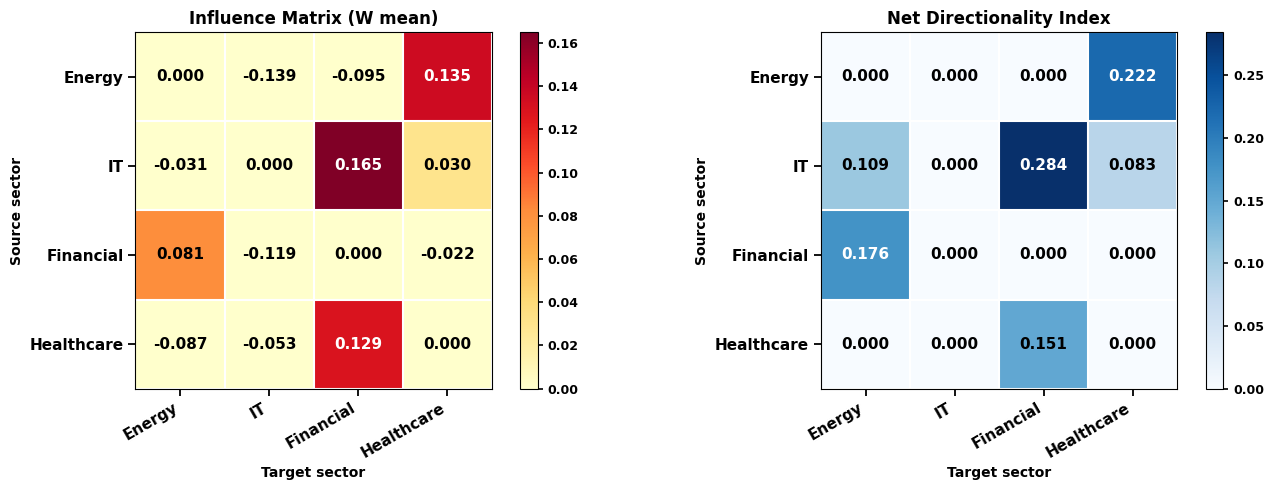

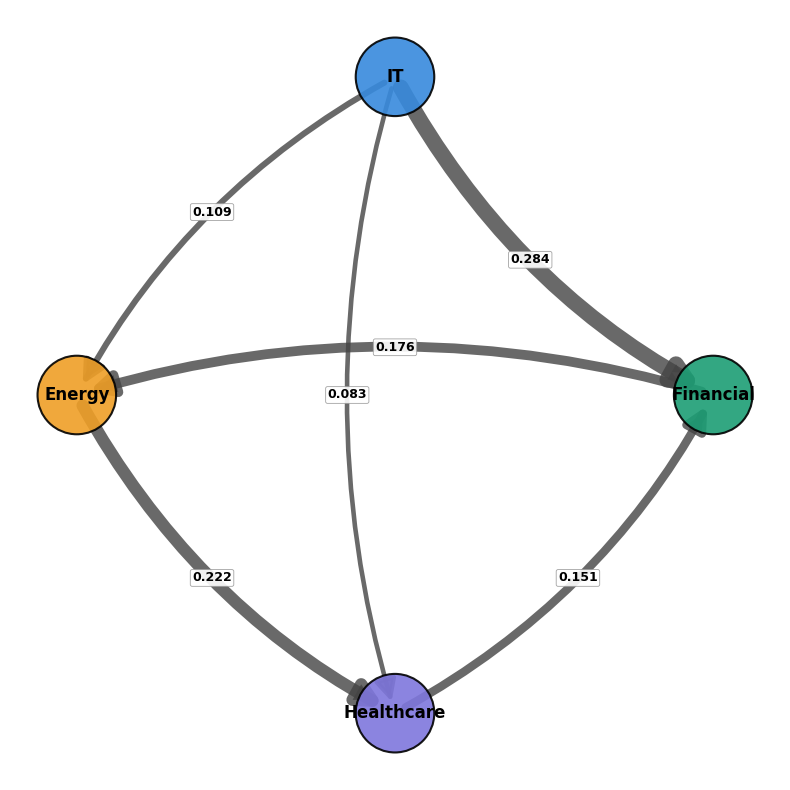


  Influence matrix:
            Energy      IT  Financial  Healthcare
Energy      0.0000 -0.0150    -0.1148      0.1274
IT         -0.1157  0.0000     0.0062     -0.0922
Financial   0.1196 -0.0334     0.0000      0.1504
Healthcare -0.0484 -0.0148     0.0213      0.0000

  Directionality Index:
            Energy      IT  Financial  Healthcare
Energy      0.0000  0.1007     0.0000      0.1758
IT          0.0000  0.0000     0.0395      0.0000
Financial   0.2345  0.0000     0.0000      0.1291
Healthcare  0.0000  0.0775     0.0000      0.0000

  Top influencer  : Financial (DI out=0.3635)
  Most influenced : Healthcare (DI in=0.3049)


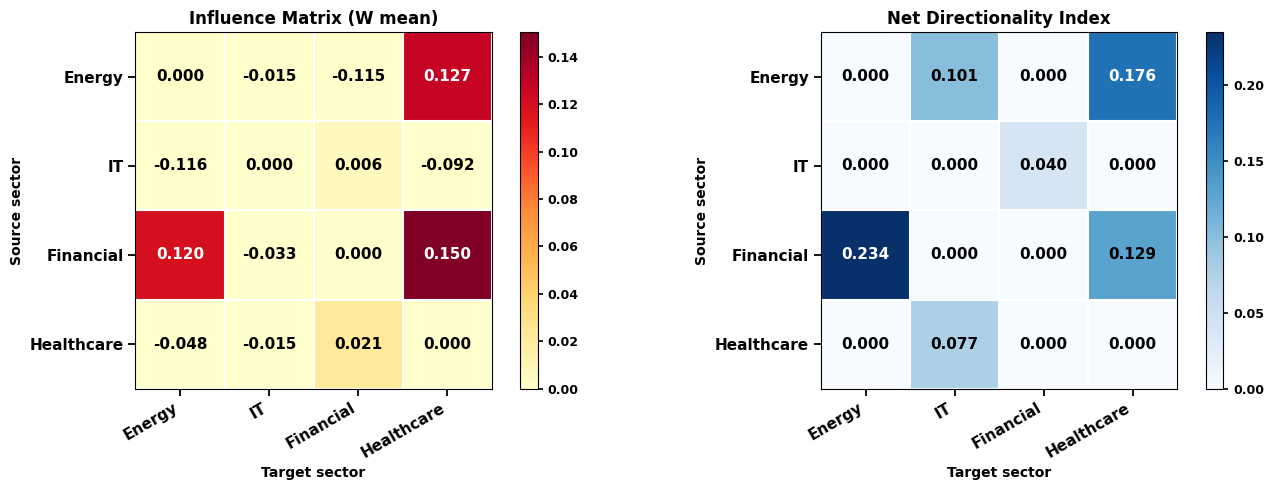

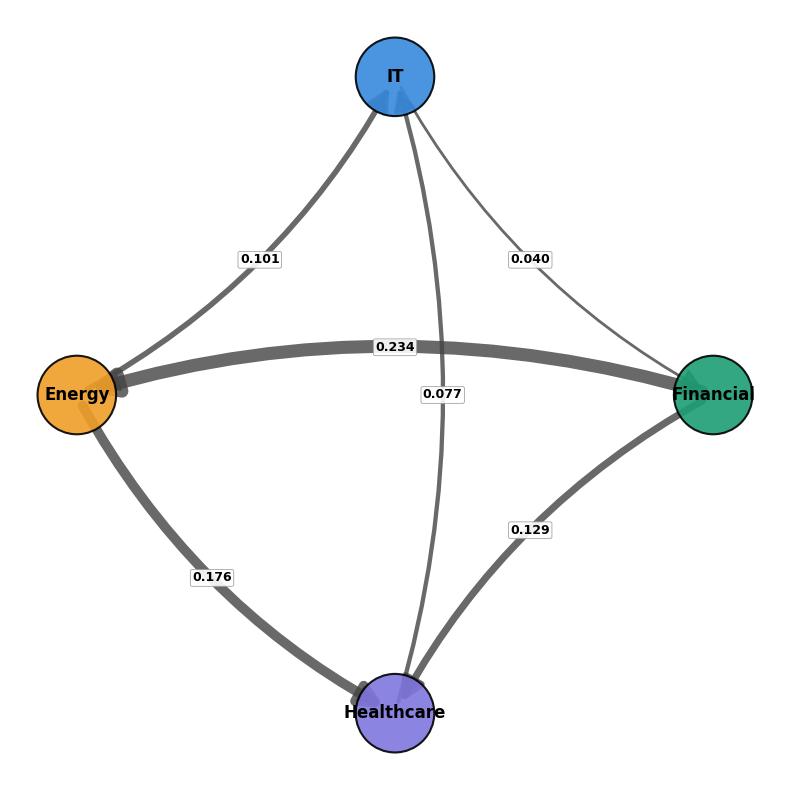


  Influence matrix:
            Energy      IT  Financial  Healthcare
Energy      0.0000  0.0407     0.0811      0.0152
IT         -0.0572  0.0000     0.0022     -0.0327
Financial   0.0356  0.0767     0.0000      0.1169
Healthcare  0.2669 -0.2367     0.2048      0.0000

  Directionality Index:
            Energy      IT  Financial  Healthcare
Energy      0.0000  0.0979     0.0456      0.0000
IT          0.0000  0.0000     0.0000      0.2041
Financial   0.0000  0.0745     0.0000      0.0000
Healthcare  0.2517  0.0000     0.0879      0.0000

  Top influencer  : Healthcare (DI out=0.3396)
  Most influenced : Energy (DI in=0.2517)


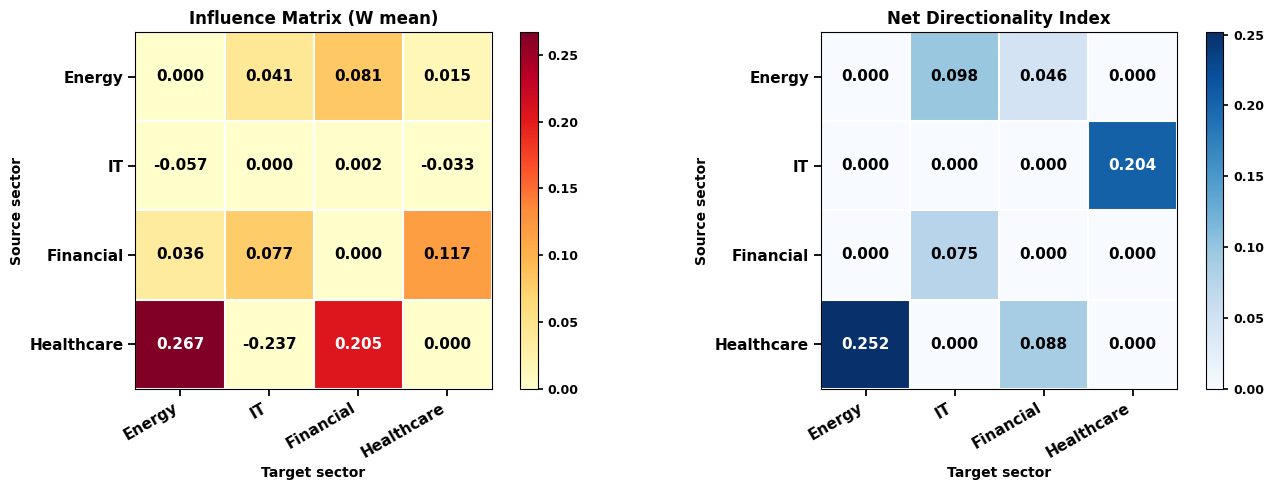

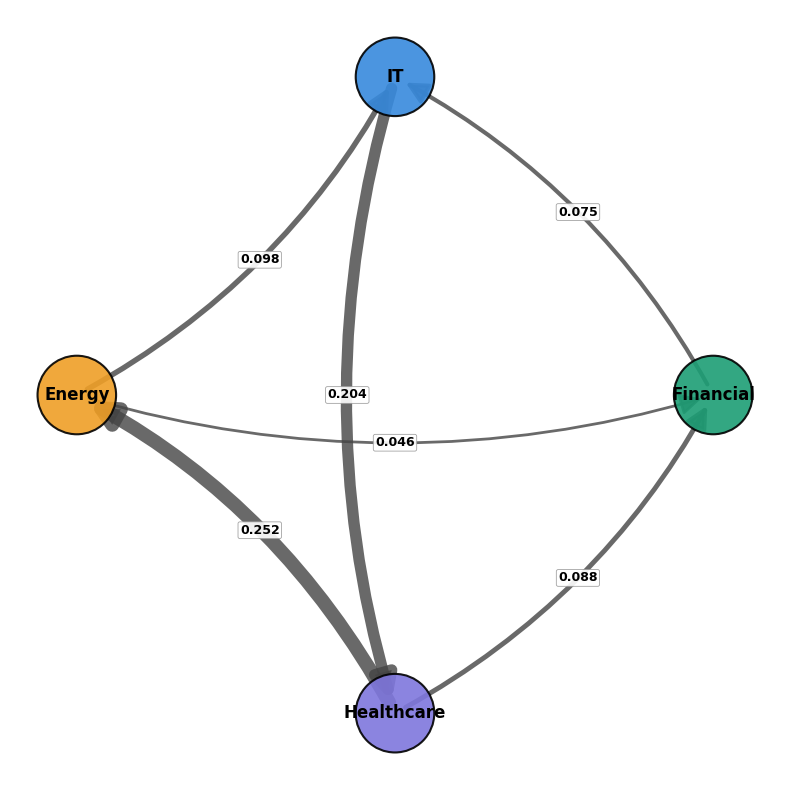


  Influence matrix:
            Energy      IT  Financial  Healthcare
Energy      0.0000  0.0144     0.0762      0.1421
IT         -0.0027  0.0000    -0.0462      0.0421
Financial  -0.1552 -0.0439     0.0000      0.0748
Healthcare  0.0597  0.0070    -0.0965      0.0000

  Directionality Index:
            Energy      IT  Financial  Healthcare
Energy         0.0  0.0171     0.2314      0.0825
IT             0.0  0.0000     0.0000      0.0351
Financial      0.0  0.0023     0.0000      0.1713
Healthcare     0.0  0.0000     0.0000      0.0000

  Top influencer  : Energy (DI out=0.3309)
  Most influenced : Healthcare (DI in=0.2888)


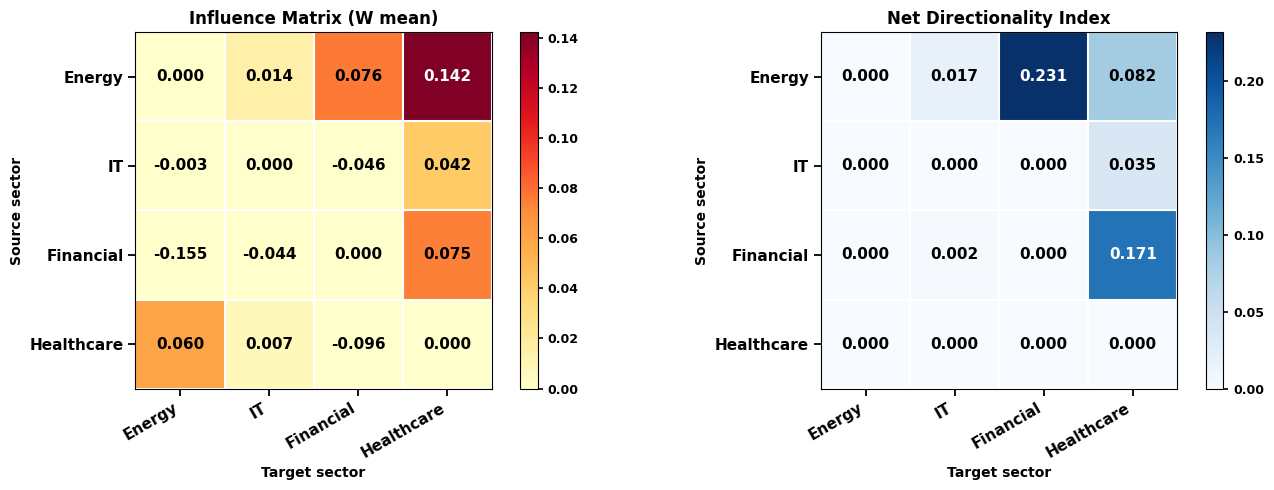

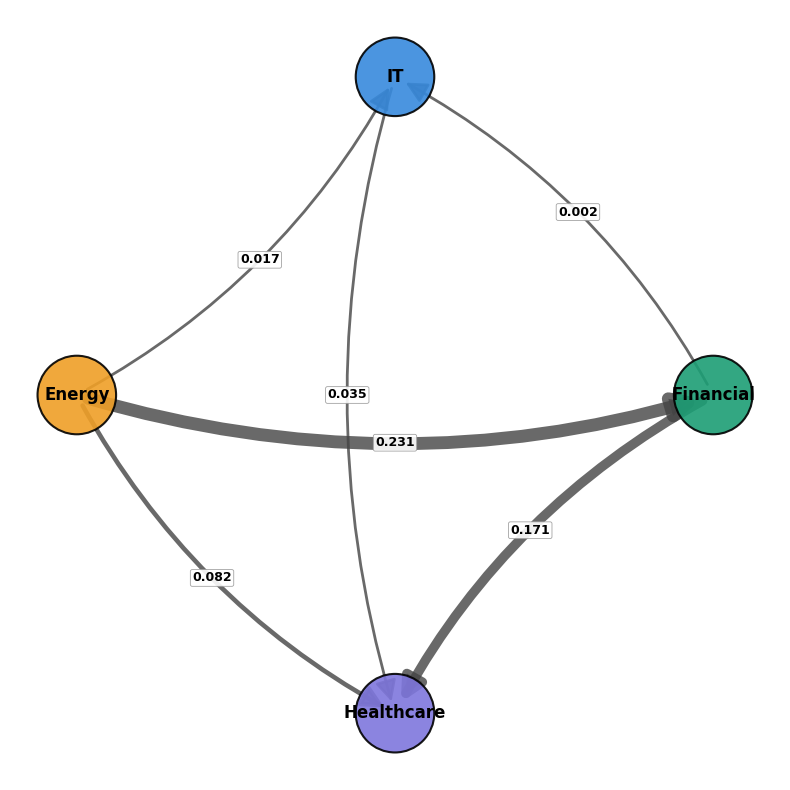

In [ ]:
# ── Main ───────────────────────────────────────────────────
print("=" * 60)
print(" Phase 9 — Inter-Sector Influence (Dense Extraction)")
print("=" * 60)

all_influence = {}
all_di        = {}
all_rows      = []

for year_idx, year_label in ALL_YEARS.items():
    print(f"\n{'='*60}")
    #print(f" {year_label} — {CRISIS_LABELS[year_label]}")
    print(f"{'='*60}")

    inf_df = build_influence_matrix(year_idx)
    di_df  = directionality_index(inf_df)

    all_influence[year_label] = inf_df
    all_di[year_label]        = di_df

    # Dominant sector analysis
    out_str = di_df.sum(axis=1)
    in_str  = di_df.sum(axis=0)
    print(f"\n  Directionality Index:")
    print(di_df.round(4).to_string())
    print(f"\n  Top influencer  : {out_str.idxmax()} "
          f"(DI out={out_str.max():.4f})")
    print(f"  Most influenced : {in_str.idxmax()} "
          f"(DI in={in_str.max():.4f})")

    # Save heatmap
    plot_heatmap(inf_df, di_df, year_label,
                 os.path.join(INTER_DIR, "heatmaps",
                              f"{year_label}.png"))

    # Save network graph
    plot_network(di_df, year_label,
                 os.path.join(INTER_DIR, "networks",
                              f"network_{year_label}.png"))

    # Store rows
    for src in SECTORS:
        for tgt in SECTORS:
            if src != tgt:
                all_rows.append({
                    "year"      : year_label,
                    #"crisis"    : CRISIS_LABELS[year_label],
                    "source"    : src,
                    "target"    : tgt,
                    "influence" : round(float(inf_df.loc[src, tgt]), 4),
                    "di"        : round(float(di_df.loc[src, tgt]), 4),
                })

 Multilayer Network — Combined 2×3 Grid
 Years: [2008, 2011, 2020, 2022]


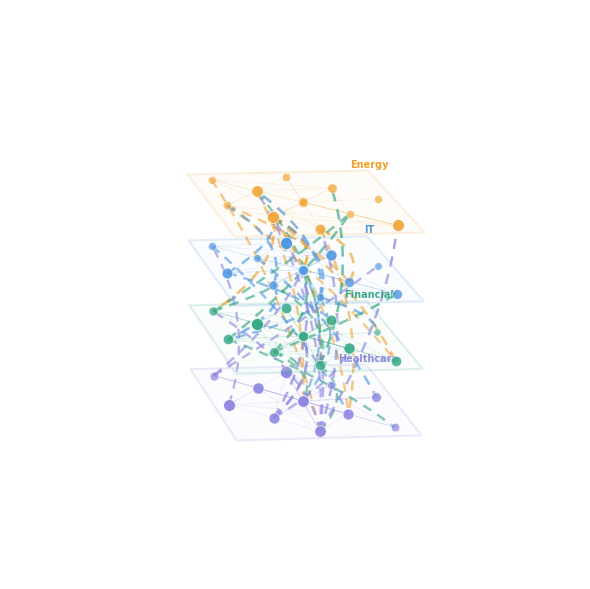

✅ Saved → /content/drive/MyDrive/MSC Thesis/ManuMultilayerNetwork/BD3d_plots/multilayer_2008.png


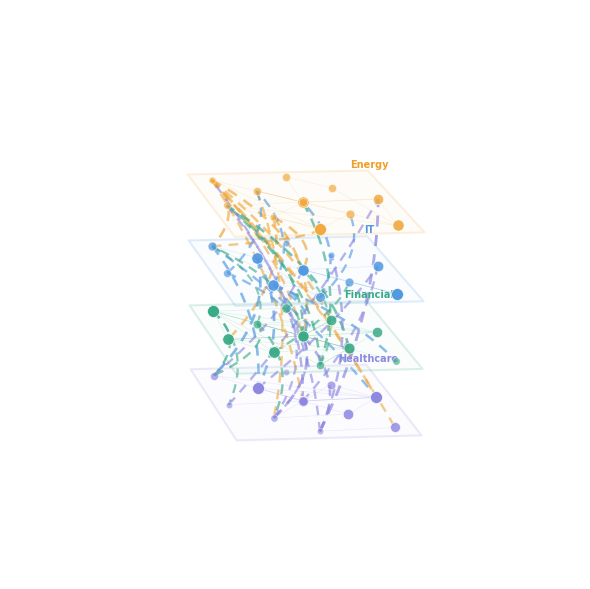

✅ Saved → /content/drive/MyDrive/MSC Thesis/ManuMultilayerNetwork/BD3d_plots/multilayer_2011.png


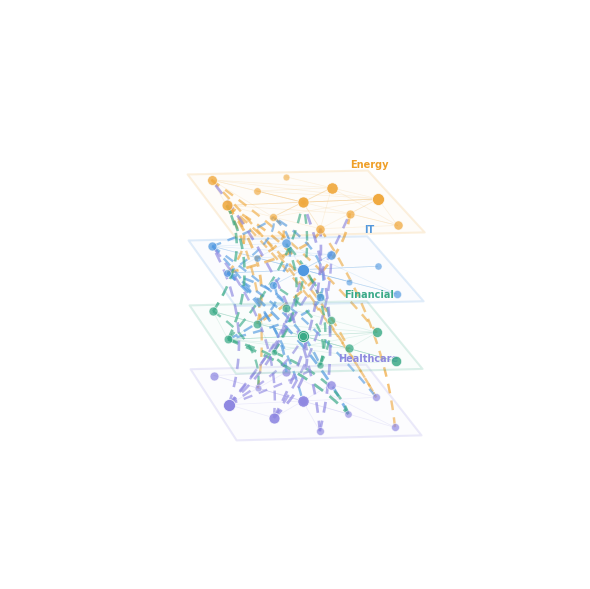

✅ Saved → /content/drive/MyDrive/MSC Thesis/ManuMultilayerNetwork/BD3d_plots/multilayer_2020.png


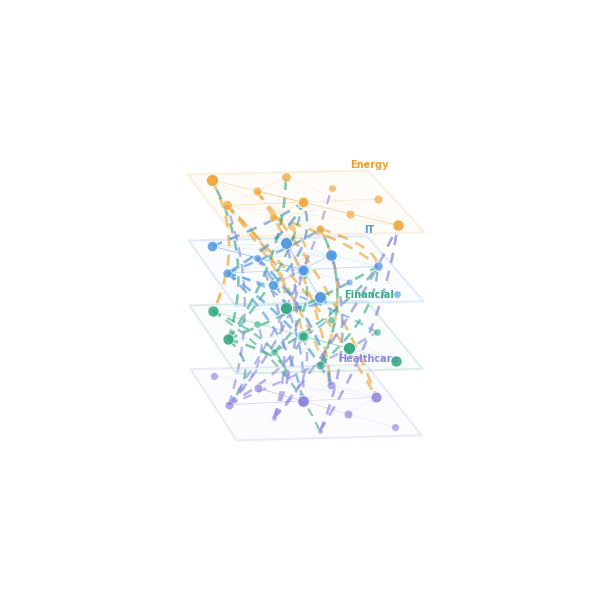

✅ Saved → /content/drive/MyDrive/MSC Thesis/ManuMultilayerNetwork/BD3d_plots/multilayer_2022.png

✅ Done!


In [ ]:
# ═══════════════════════════════════════════════════════════
# Phase 10 — 3D Multilayer Network (Diamond Layers)
# Combined 2×2 subplot figure for 6 selected years
# ═══════════════════════════════════════════════════════════

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

BASE_DIR  = "/content/drive/MyDrive/MSC Thesis"
ADJ_DIR   = os.path.join(BASE_DIR, "BDAdjacencyMatrices_Dense")
INTER_DIR = os.path.join(BASE_DIR, "InterSectorDense", "matrices")
MULTI_DIR = os.path.join(BASE_DIR, "ManuMultilayerNetwork", "BD3d_plots")
os.makedirs(MULTI_DIR, exist_ok=True)

SECTORS = ["Energy", "IT", "Financial", "Healthcare"]

SECTOR_COLORS = {
    "Energy"    : "#EF9F27",
    "IT"        : "#378ADD",
    "Financial" : "#1D9E75",
    "Healthcare": "#7F77DD",
}
SECTOR_LIGHT = {
    "Energy"    : "#FAEEDA",
    "IT"        : "#E6F1FB",
    "Financial" : "#E1F5EE",
    "Healthcare": "#EEEDFE",
}
SECTOR_TICKERS = {
    "Energy"    : ["APA","COP","CVX","DVN","EOG","FLR","FTI",
                   "HAL","NFG","OKE","OXY","SLB","VLO","WMB","XOM"],
    "IT"        : ["AAPL","MSFT","NVDA","ORCL","CRM","AMD","QCOM",
                   "TXN","INTC","IBM","CSCO","AMAT","ADI","MU","ADBE"],
    "Financial" : ["JPM","BAC","WFC","GS","MS","C","BLK","SCHW",
                   "AXP","USB","PNC","COF","BK","STT","CME"],
    "Healthcare": ["JNJ","UNH","LLY","ABT","TMO","MRK","DHR","ABBV",
                   "PFE","BMY","AMGN","GILD","SYK","MDT","BSX"],
}

# 6 years for 2×2 grid
PLOT_YEARS = [

    (3,  2008, "GFC Peak"),
    (6,  2011, "ESD Crisis"),

    (15, 2020, "COVID-19"),
    (17, 2022, "Russia-Ukraine"),
]

N_STOCKS   = 15
LAYER_Z    = {"Energy": 9.0, "IT": 6.0,
              "Financial": 3.0, "Healthcare": 0.0}
DIAMOND_DX = 1.8
DIAMOND_DY = 1.1


# ── Geometry helpers ───────────────────────────────────────

def diamond_corners(z, pad=0.0):
    dx = DIAMOND_DX + pad
    dy = DIAMOND_DY + pad
    return [(0, dy, z), (dx, 0, z), (0, -dy, z), (-dx, 0, z)]


def get_node_positions(sector, z):
    row_y    = [-0.55, 0.0, 0.55]
    row_cols = [3, 5, 3]
    flat_pos = []
    for y_val, ncols in zip(row_y, row_cols):
        max_x = DIAMOND_DX * (1 - abs(y_val)/DIAMOND_DY) * 0.85
        xs    = [0.0] if ncols == 1 \
                else np.linspace(-max_x, max_x, ncols).tolist()
        for x_val in xs:
            flat_pos.append((x_val, y_val, z))
    while len(flat_pos) < N_STOCKS:
        flat_pos.append((0, 0, z))
    return flat_pos[:N_STOCKS]


# ── Drawing functions ──────────────────────────────────────

def draw_diamond_plane(ax, sector, z, alpha=0.15):
    corners = diamond_corners(z, pad=0.15)
    plane   = Poly3DCollection([corners], alpha=alpha, zorder=1)
    plane.set_facecolor(SECTOR_LIGHT[sector])
    plane.set_edgecolor(SECTOR_COLORS[sector])
    plane.set_linewidth(1.5)
    ax.add_collection3d(plane)
    ax.text(0, DIAMOND_DY + 0.2, z, sector,
            fontsize=7, fontweight='bold',
            color=SECTOR_COLORS[sector],
            ha='center', va='bottom', zorder=10)


def draw_nodes(ax, sector, z, adj_df):
    positions = get_node_positions(sector, z)
    color     = SECTOR_COLORS[sector]
    degrees   = (adj_df.values.sum(axis=1) +
                 adj_df.values.sum(axis=0)) \
                if adj_df is not None \
                else np.ones(N_STOCKS) * 3
    max_deg = max(degrees.max(), 1)
    for i, (x, y, nz) in enumerate(positions):
        size  = 15 + (degrees[i] / max_deg) * 60
        alpha = 0.55 + (degrees[i] / max_deg) * 0.45
        ax.scatter(x, y, nz, s=size, c=color, alpha=alpha,
                   edgecolors='white', linewidths=0.5,
                   zorder=5, depthshade=False)


def draw_intra_edges(ax, sector, z, adj_df):
    if adj_df is None:
        return
    positions = get_node_positions(sector, z)
    color     = SECTOR_COLORS[sector]
    A         = adj_df.values
    for i in range(N_STOCKS):
        for j in range(i+1, N_STOCKS):
            if A[i, j] == 1:
                x1, y1, _ = positions[i]
                x2, y2, _ = positions[j]
                ax.plot([x1, x2], [y1, y2], [z, z],
                        color=color, alpha=0.15,
                        linewidth=0.5, zorder=3)


def draw_cross_arcs(ax, src, tgt, cross_w_df,
                    z_src, z_tgt, max_arcs=4):
    if cross_w_df is None:
        return
    W          = np.abs(cross_w_df.values)
    src_pos    = get_node_positions(src, z_src)
    tgt_pos    = get_node_positions(tgt, z_tgt)
    color      = SECTOR_COLORS[src]
    top_thresh = np.percentile(W, 92)
    drawn      = 0
    for i in range(N_STOCKS):
        for j in range(N_STOCKS):
            if W[i, j] > top_thresh and drawn < max_arcs:
                x1, y1, _ = src_pos[i]
                x2, y2, _ = tgt_pos[j]
                mid_z      = (z_src + z_tgt) / 2
                t          = np.linspace(0, 1, 20)
                bx = ((1-t)**2*x1
                      + 2*(1-t)*t*(x1*0.6+x2*0.4+0.3)
                      + t**2*x2)
                by = ((1-t)**2*y1
                      + 2*(1-t)*t*(y1*0.6+y2*0.4+0.3)
                      + t**2*y2)
                bz = ((1-t)**2*z_src
                      + 2*(1-t)*t*mid_z
                      + t**2*z_tgt)
                w_norm = W[i, j] / (W.max() + 1e-8)
                ax.plot(bx, by, bz, color=color,
                        alpha=0.4 + w_norm*0.3,
                        linewidth=0.8 + w_norm*1.2,
                        linestyle='--', dashes=(4, 3),
                        zorder=4)
                drawn += 1


def draw_one_year(ax, year_idx, year_label, crisis_label):
    """Draw one year's multilayer network onto a given 3D axis."""

    for sector in reversed(SECTORS):
        z        = LAYER_Z[sector]
        adj_path = os.path.join(
            ADJ_DIR, sector, f"year_{year_idx:02d}.csv")
        adj_df   = pd.read_csv(adj_path, index_col=0) \
                   if os.path.exists(adj_path) else None
        draw_diamond_plane(ax, sector, z)
        draw_intra_edges(ax, sector, z, adj_df)
        draw_nodes(ax, sector, z, adj_df)

    for src in SECTORS:
        for tgt in SECTORS:
            if src == tgt:
                continue
            cross_path = os.path.join(
                INTER_DIR,
                f"{src}_to_{tgt}_{year_label}.csv")
            if not os.path.exists(cross_path):
                continue
            cross_df = pd.read_csv(cross_path, index_col=0)
            draw_cross_arcs(ax, src, tgt, cross_df,
                            LAYER_Z[src], LAYER_Z[tgt])

    ax.view_init(elev=22, azim=-55)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.0, 2.0)
    ax.set_zlim(-0.5, 11.0)
    ax.set_axis_off()
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('white')
    ax.yaxis.pane.set_edgecolor('white')
    ax.zaxis.pane.set_edgecolor('white')
    ax.grid(False)

    # Panel title — tight, no pad
    ax.set_title(f"{year_label} — {crisis_label}",
                 fontsize=10, fontweight='bold',
                 color='#333333', pad=0)


# ── Individual figures (no caption) ─────────────────────────────



def plot_individual():

    for year_idx, year_label, crisis_label in PLOT_YEARS:

        fig = plt.figure(figsize=(6, 7), facecolor="white")
        ax = fig.add_subplot(111, projection="3d")
        ax.set_facecolor("white")

        draw_one_year(ax, year_idx, year_label, crisis_label)

        # Remove the title
        ax.set_title("")

        plt.tight_layout()

        local = f"/content/multilayer_{year_label}.png"

        plt.savefig(
            local,
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.02,
            facecolor="white"
        )

        plt.show()
        plt.close()

        save_path = os.path.join(
            MULTI_DIR,
            f"multilayer_{year_label}.png"
        )

        try:
            shutil.copy(local, save_path)
            os.remove(local)
            print(f"✅ Saved → {save_path}")
        except:
            print(f"⚠️ Kept locally: {local}")

# ── Run ────────────────────────────────────────────────────
print("=" * 60)
print(" Multilayer Network — Combined 2×3 Grid")
print(f" Years: {[y for _,y,_ in PLOT_YEARS]}")
print("=" * 60)

plot_individual()
print("\n✅ Done!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Evaluation 1 — Multilayer Metrics, 2005-2024
  Computing global cross-sector threshold (20-year pool) ...
  μ_all   = 0.3289
  σ_all   = 0.2277
  θ_fixed = 0.7842  (μ + 2σ, pooled over 240 matrices)
  This keeps only the top 4.0% of cross-sector connections

[00] 2005 
     density=0.0328  coupling=0.5431  cluster=0.0582  GRC=0.2330  P=0.3569  interdep=0.8991

[01] 2006 
     density=0.0514  coupling=0.4670  cluster=0.1202  GRC=0.2100  P=0.4205  interdep=0.8209

[02] 2007 
     density=0.0802  coupling=0.4331  cluster=0.1833  GRC=0.0572  P=0.4759  interdep=0.9168

[03] 2008 — GFC Peak
     density=0.1438  coupling=0.3026  cluster=0.3424  GRC=0.0327  P=0.4294  interdep=0.8985

[04] 2009 — Post-GFC Recovery
     density=0.1020  coupling=0.3518  cluster=0.2408  GRC=0.0945  P=0.4453  interdep=0.9145

[05] 2010 
     density=0.0664  coupling=0.4170  cluster=0.138

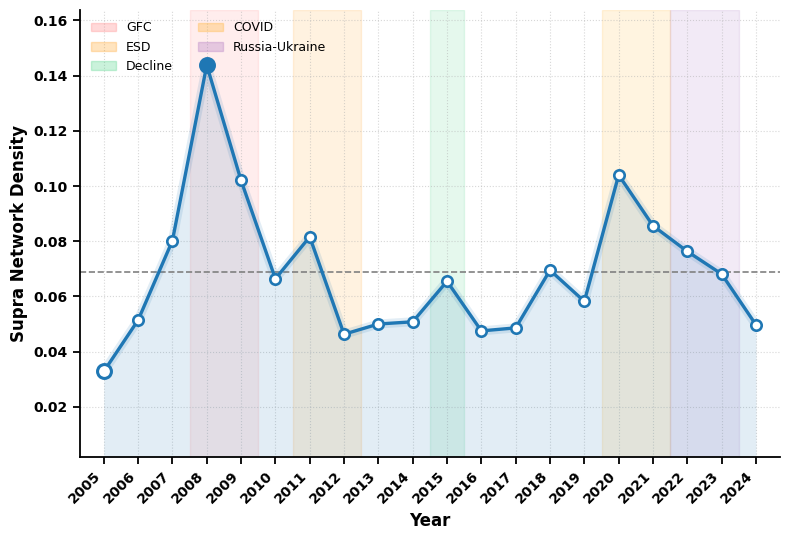

Saved -> /content/drive/MyDrive/MSC Thesis/Manu_Full20/supra_density.png


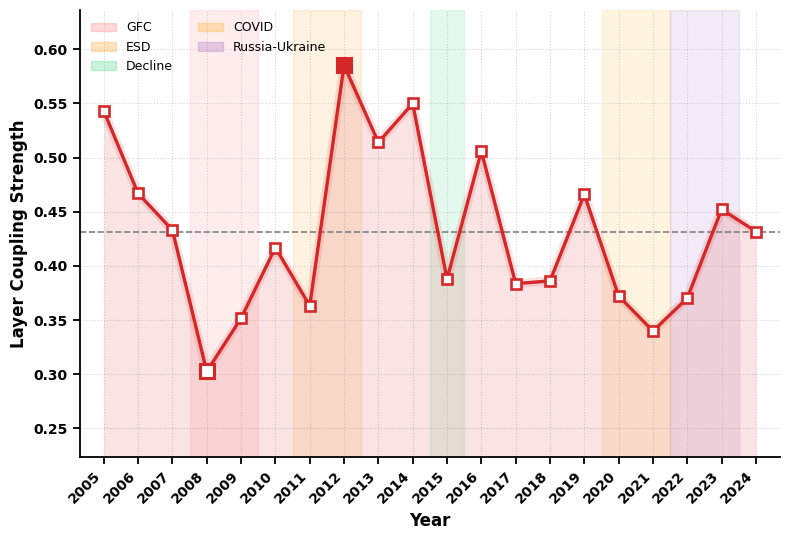

Saved -> /content/drive/MyDrive/MSC Thesis/Manu_Full20/layer_coupling.png


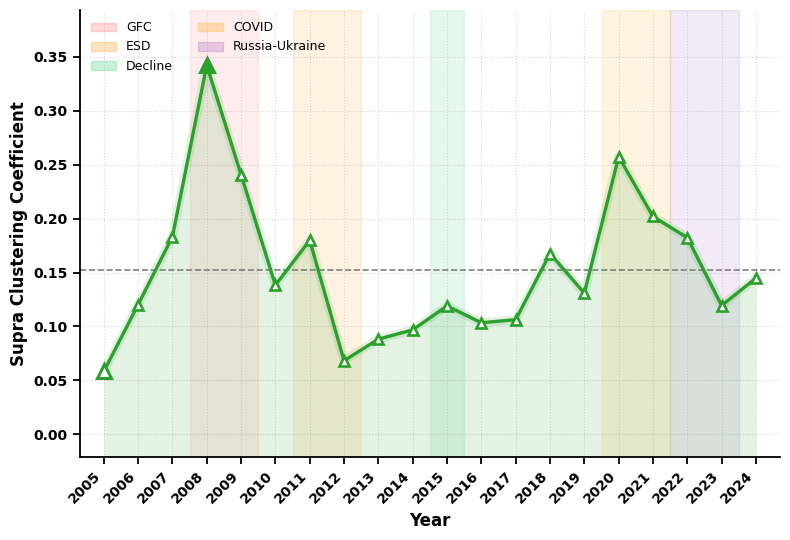

Saved -> /content/drive/MyDrive/MSC Thesis/Manu_Full20/supra_clustering.png


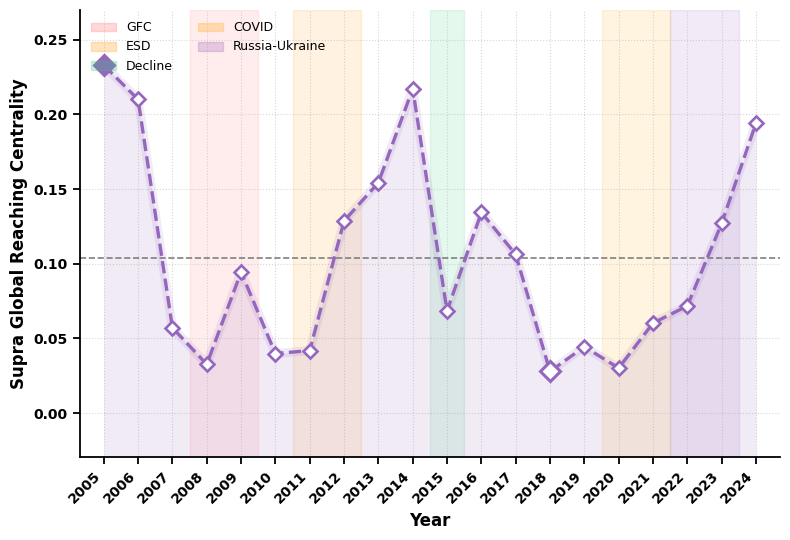

Saved -> /content/drive/MyDrive/MSC Thesis/Manu_Full20/supra_grc.png


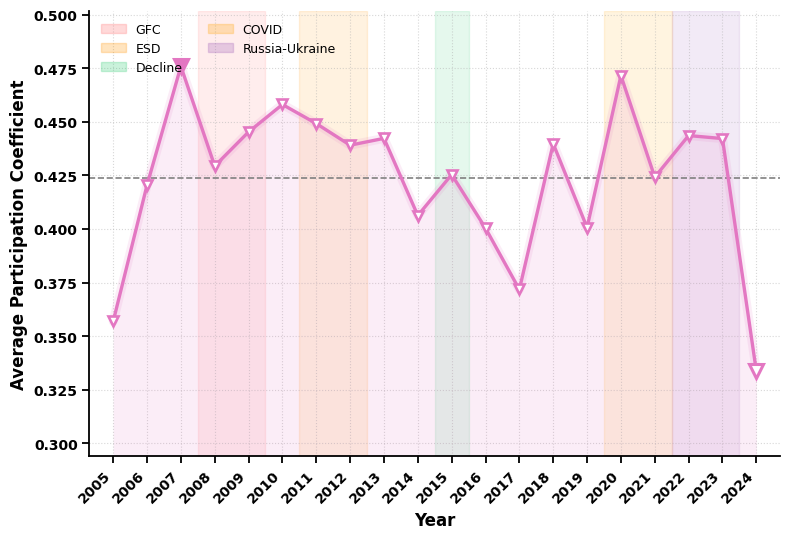

Saved -> /content/drive/MyDrive/MSC Thesis/Manu_Full20/participation.png


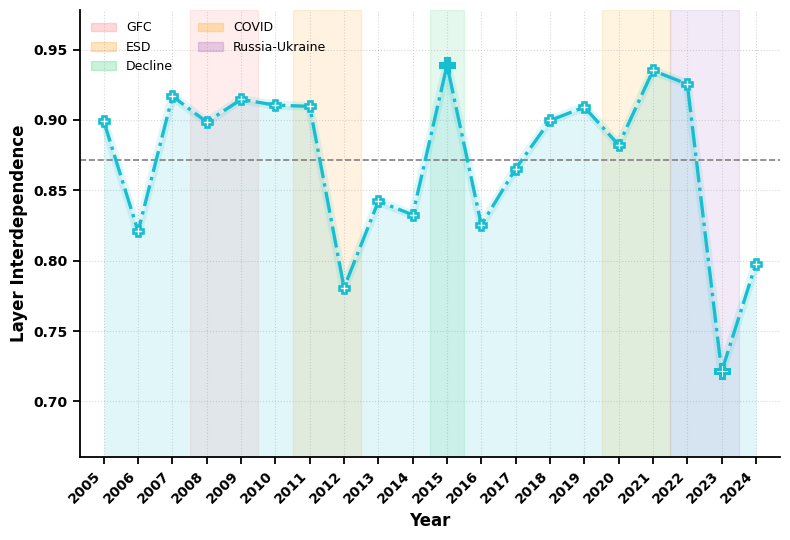

Saved -> /content/drive/MyDrive/MSC Thesis/Manu_Full20/interdependence.png

 Key Multilayer Findings (Full 20-Year)

  Supra-density:
    Peak : 0.1438 (2008 — GFC Peak)
    Min  : 0.0328 (2005 — Normal)
    Mean : 0.0689 ± 0.0259

  Layer coupling:
    Peak : 0.5854 (2012 — ESD Continuation)
    Min  : 0.3026 (2008 — GFC Peak)
    Mean : 0.4312 ± 0.0778

  Supra-GRC:
    Peak : 0.2330 (2005 — Normal)
    Min  : 0.0279 (2018 — Normal)
    Mean : 0.1037 ± 0.0680

  Supra-clustering:
    Peak : 0.3424 (2008 — GFC Peak)
    Min  : 0.0582 (2005 — Normal)
    Mean : 0.1525 ± 0.0696

  Participation:
    Peak : 0.4759 (2007 — Normal)
    Min  : 0.3338 (2024 — Normal)
    Mean : 0.4238 ± 0.0367

  Interdependence:
    Peak : 0.9389 (2015 — Global Decline)
    Min  : 0.7213 (2023 — Russia-Ukraine Continuation)
    Mean : 0.8713 ± 0.0587

  Cross-sector θ used : 0.7842
  Crisis years (9) : [2008, 2009, 2011, 2012, 2015, 2020, 2021, 2022, 2023]

✅ Evaluation 1 (Full 20-Year) complete!


In [ ]:
# ═══════════════════════════════════════════════════════════
# Evaluation 1 — Multilayer Network Metrics (Full 20-Year)
# Extended from 9 significant years to all 20 years (2005-2024)
# Global cross-sector threshold θ = μ_all + 2σ_all
# pooled across all 12 pairs × 20 years = 240 matrices
# ═══════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BASE_DIR  = "/content/drive/MyDrive/MSC Thesis"
ADJ_DIR   = os.path.join(BASE_DIR, "BDAdjacencyMatrices_Dense")
INTER_DIR = os.path.join(BASE_DIR, "BDInterSectorDense", "matrices")
EVAL_DIR  = os.path.join(BASE_DIR, "Manu_Full20")
os.makedirs(EVAL_DIR, exist_ok=True)

SECTORS = ["Energy", "IT", "Financial", "Healthcare"]

SECTOR_TICKERS = {
    "Energy"    : ["APA","COP","CVX","DVN","EOG","FLR","FTI",
                   "HAL","NFG","OKE","OXY","SLB","VLO","WMB","XOM"],
    "IT"        : ["AAPL","MSFT","NVDA","ORCL","CRM","AMD","QCOM",
                   "TXN","INTC","IBM","CSCO","AMAT","ADI","MU","ADBE"],
    "Financial" : ["JPM","BAC","WFC","GS","MS","C","BLK","SCHW",
                   "AXP","USB","PNC","COF","BK","STT","CME"],
    "Healthcare": ["JNJ","UNH","LLY","ABT","TMO","MRK","DHR","ABBV",
                   "PFE","BMY","AMGN","GILD","SYK","MDT","BSX"],
}

# ── ALL 20 YEARS ─────────────────────────────────────────
ALL_YEARS = {idx: 2005 + idx for idx in range(20)}

CRISIS_LABELS = {
    2005: "", 2006: "", 2007: "",
    2008: "GFC Peak",
    2009: "Post-GFC Recovery",
    2010: "",
    2011: "ESD Crisis",
    2012: "ESD Continuation",
    2013: "", 2014: "",
    2015: "Global Decline",
    2016: "", 2017: "", 2018: "", 2019: "",
    2020: "COVID-19",
    2021: "COVID Recovery",
    2022: "Russia-Ukraine",
    2023: "Russia-Ukraine Continuation",
    2024: "",
}

# FIX: derived from CRISIS_LABELS so shading and labels can never disagree
CRISIS_YEARS = [y for y, lab in CRISIS_LABELS.items() if lab != ""]

CRISIS_PERIODS = [
    (2008, 2009, "#FF6B6B", "GFC"),
    (2011, 2012, "#FF9500", "ESD"),
    (2015, 2015, "#2ECC71", "Decline"),
    (2020, 2021, "#FFA500", "COVID"),
    (2022, 2023, "#9B59B6", "Russia-Ukraine"),
]

N_STOCKS  = 15
N_SECTORS = 4
N_TOTAL   = N_STOCKS * N_SECTORS   # 60

# Binarize intra-sector blocks if the stored matrices are weighted.
# Keeps intra/inter counting in compute_coupling() consistent.
BINARIZE_INTRA = True

_CROSS_CACHE = {}   # FIX: avoid re-reading the same CSV 180× per year


# ── Step 0: Compute global cross-sector threshold ──────────
def compute_global_cross_threshold():
    """
    Concatenate ALL cross-sector W matrices across all pairs
    and all 20 years → compute θ = μ_all + 2σ_all
    Pool size: 12 pairs × 20 years = 240 matrices
    """
    print("  Computing global cross-sector threshold (20-year pool) ...")
    all_vals  = []
    n_matrices = 0

    for src in SECTORS:
        for tgt in SECTORS:
            if src == tgt:
                continue
            for year_label in ALL_YEARS.values():
                path = os.path.join(
                    INTER_DIR, f"{src}_to_{tgt}_{year_label}.csv")
                if os.path.exists(path):
                    W = np.abs(pd.read_csv(path, index_col=0).values)
                    all_vals.append(W.flatten())
                    n_matrices += 1

    if not all_vals:
        print("  ⚠️ No cross-sector matrices found")
        return 0.5

    all_vals  = np.concatenate(all_vals)
    mu_all    = all_vals.mean()
    sigma_all = all_vals.std()
    theta     = mu_all + 2 * sigma_all

    kept = 100 * (all_vals > theta).mean()     # FIX: was inverted (1 - ...)

    print(f"  μ_all   = {mu_all:.4f}")
    print(f"  σ_all   = {sigma_all:.4f}")
    print(f"  θ_fixed = {theta:.4f}  (μ + 2σ, pooled over "
          f"{n_matrices} matrices)")
    print(f"  This keeps only the top {kept:.1f}% "
          f"of cross-sector connections")
    return theta


# ── Loaders ────────────────────────────────────────────────
def load_adj(sector, year_idx):
    path = os.path.join(ADJ_DIR, sector, f"year_{year_idx:02d}.csv")
    if not os.path.exists(path):
        return None
    return pd.read_csv(path, index_col=0)


def load_cross(src, tgt, year_label):
    key = (src, tgt, year_label)
    if key in _CROSS_CACHE:
        return _CROSS_CACHE[key]
    path = os.path.join(INTER_DIR, f"{src}_to_{tgt}_{year_label}.csv")
    df = pd.read_csv(path, index_col=0) if os.path.exists(path) else None
    _CROSS_CACHE[key] = df
    return df


def threshold_cross(W_df, theta):
    W = np.abs(W_df.values)
    A = (W > theta).astype(int)
    np.fill_diagonal(A, 0)
    return A


# ── Build supra-adjacency matrix ──────────────────────────
def build_supra(year_idx, year_label, theta):
    all_tickers = []
    for s in SECTORS:
        all_tickers.extend(SECTOR_TICKERS[s])

    supra = np.zeros((N_TOTAL, N_TOTAL))

    # Diagonal — intra-sector
    for si, sector in enumerate(SECTORS):
        A_df = load_adj(sector, year_idx)
        if A_df is None:
            print(f"    ⚠️ missing intra matrix: {sector} year_{year_idx:02d}")
            continue
        rs, re = si * N_STOCKS, si * N_STOCKS + N_STOCKS
        A = A_df.values.astype(float).copy()
        np.fill_diagonal(A, 0)
        if BINARIZE_INTRA:
            A = (np.abs(A) > 0).astype(float)
        supra[rs:re, rs:re] = A

    # Off-diagonal — cross-sector
    for si, src in enumerate(SECTORS):
        for ti, tgt in enumerate(SECTORS):
            if src == tgt:
                continue
            W_df = load_cross(src, tgt, year_label)
            if W_df is None:
                continue
            A_cross = threshold_cross(W_df, theta)
            rs, re = si * N_STOCKS, si * N_STOCKS + N_STOCKS
            cs, ce = ti * N_STOCKS, ti * N_STOCKS + N_STOCKS
            supra[rs:re, cs:ce] = A_cross

    np.fill_diagonal(supra, 0)
    return pd.DataFrame(supra, index=all_tickers, columns=all_tickers)


# ── Metrics ────────────────────────────────────────────────
def get_sector_idx(ticker):
    for si, s in enumerate(SECTORS):
        if ticker in SECTOR_TICKERS[s]:
            return si
    return -1


def compute_supra_density(supra_df):
    A = supra_df.values.copy()
    np.fill_diagonal(A, 0)
    n = A.shape[0]
    return round((A != 0).sum() / (n * (n - 1)), 4)


def compute_coupling(supra_df):
    A       = supra_df.values
    tickers = list(supra_df.columns)
    sect    = np.array([get_sector_idx(t) for t in tickers])

    E = (A != 0)                     # FIX: was A == 1 (dropped weighted edges)
    np.fill_diagonal(E, False)

    same  = sect[:, None] == sect[None, :]
    intra = int(E[same].sum())
    inter = int(E[~same].sum())
    total = intra + inter
    coupling = inter / total if total > 0 else 0.0
    return intra, inter, total, round(coupling, 4)


def compute_participation(supra_df):
    """
    Guimera-Amaral participation coefficient computed on the supra matrix:
        P_i = 1 - Σ_s (k_is / k_i)^2
    Also reports the simpler cross-sector reach ratio for comparison.
    """
    A       = (supra_df.values != 0).astype(float)
    tickers = list(supra_df.columns)
    sect    = np.array([get_sector_idx(t) for t in tickers])

    records = []
    for i, tk in enumerate(tickers):
        k_i = A[i].sum() + A[:, i].sum()          # total degree (in + out)
        if k_i == 0:
            p_gm, reach = 0.0, 0
        else:
            ssum = 0.0
            for s in range(N_SECTORS):
                mask = (sect == s)
                k_is = A[i, mask].sum() + A[mask, i].sum()
                ssum += (k_is / k_i) ** 2
            p_gm = 1.0 - ssum
            reach = sum(
                1 for s in range(N_SECTORS)
                if s != sect[i] and
                (A[i, sect == s].sum() + A[sect == s, i].sum()) > 0
            )
        records.append({"ticker": tk, "sector": SECTORS[sect[i]],
                        "p_gm": round(p_gm, 4),
                        "reach": round(reach / (N_SECTORS - 1), 4),
                        "n_sectors": reach})

    pdf   = pd.DataFrame(records)
    avg_p = round(pdf["p_gm"].mean(), 4)
    top5  = pdf.sort_values(["p_gm", "n_sectors"],
                            ascending=False).head(5)
    return avg_p, top5


def compute_supra_grc(supra_df):
    A = (supra_df.values != 0).astype(float)
    np.fill_diagonal(A, 0)
    if A.sum() == 0:
        return 0.0
    G = nx.from_numpy_array(A, create_using=nx.DiGraph())
    try:
        return round(nx.global_reaching_centrality(G), 4)
    except Exception:
        pass
    try:
        G_u = G.to_undirected()
        n   = G_u.number_of_nodes()
        lrc = {}
        for node in G_u.nodes():
            reachable = nx.single_source_shortest_path_length(G_u, node)
            lrc[node] = (len(reachable) - 1) / (n - 1) if n > 1 else 0
        max_lrc = max(lrc.values()) if lrc else 0
        grc = sum(max_lrc - v for v in lrc.values()) / (n - 1) if n > 1 else 0
        return round(grc, 4)
    except Exception as e:
        print(f"    GRC fallback failed: {e}")
        return 0.0


def compute_supra_clustering(supra_df):
    A = (supra_df.values != 0).astype(float)
    np.fill_diagonal(A, 0)
    G = nx.from_numpy_array(A, create_using=nx.DiGraph())
    try:
        return round(nx.average_clustering(G), 4)
    except Exception:
        return 0.0


def compute_interdependence(year_idx):
    """
    Layer interdependence = mean Pearson correlation between the
    DEGREE SEQUENCES of the four intra-sector layers.

    NOTE: correlating flattened adjacency matrices (the previous version)
    is not meaningful — element (i,j) refers to different stock pairs in
    different sectors, so the value depends on ticker ordering.
    Degree sequences are order-consistent within a layer and give a
    defensible structural-similarity measure.
    """
    degs = {}
    for s in SECTORS:
        A_df = load_adj(s, year_idx)
        if A_df is None:
            continue
        A = (np.abs(A_df.values.astype(float)) > 0).astype(float)
        np.fill_diagonal(A, 0)
        d = np.sort(A.sum(axis=1))[::-1]      # sorted degree sequence
        degs[s] = d

    if len(degs) < 2:
        return 0.0

    corrs, slist = [], list(degs.keys())
    for i in range(len(slist)):
        for j in range(i + 1, len(slist)):
            a, b = degs[slist[i]], degs[slist[j]]
            if a.std() == 0 or b.std() == 0:
                continue
            r = np.corrcoef(a, b)[0, 1]
            if not np.isnan(r):
                corrs.append(r)

    return round(float(np.mean(corrs)), 4) if corrs else 0.0


# ── Plot — Individual Publication-Ready Figures ────────────
def plot_metrics(df):

    years = df["year"].tolist()

    # (column, y-label, colour, marker, linestyle, filename)
    metrics = [
        ("supra_density", "Supra Network Density",             "#1f77b4", 'o', '-',   "supra_density.png"),
        ("coupling",      "Layer Coupling Strength",           "#d62728", 's', '-',   "layer_coupling.png"),
        ("supra_cluster", "Supra Clustering Coefficient",      "#2ca02c", '^', '-',   "supra_clustering.png"),
        ("supra_grc",     "Supra Global Reaching Centrality",  "#9467bd", 'D', '--',  "supra_grc.png"),
        ("avg_p",         "Average Participation Coefficient", "#e377c2", 'v', '-',   "participation.png"),
        ("interdep",      "Layer Interdependence",             "#17becf", 'P', '-.',  "interdependence.png"),
    ]

    plt.rcParams["font.family"] = "sans-serif"

    for idx, (col, ylabel, color, marker, ls, filename) in enumerate(metrics):

        vals = df[col].values
        fig, ax = plt.subplots(figsize=(8, 5.5))

        # Crisis regions — FIX: ±0.5 padding so single-year spans are visible
        for start, end, ccolor, _ in CRISIS_PERIODS:
            ax.axvspan(start - 0.5, end + 0.5,
                       color=ccolor, alpha=0.12, zorder=0)

        ax.axhline(np.mean(vals), color="gray",
                   linestyle="--", linewidth=1.2)

        # ── Uniform aesthetic line style for every metric ──────
        vmin, vmax = float(np.min(vals)), float(np.max(vals))
        span = (vmax - vmin) if vmax > vmin else max(abs(vmax), 1e-6)
        base = vmin - 0.28 * span          # baseline for the gradient fill

        # soft shadow under the curve
        ax.fill_between(years, vals, base, color=color,
                        alpha=0.13, linewidth=0, zorder=1)

        # glow underlay for a softer, thicker edge
        ax.plot(years, vals, color=color, linewidth=6.5, alpha=0.13,
                solid_capstyle='round', zorder=2)

        # main line
        ax.plot(years, vals, color=color, linewidth=2.4, linestyle=ls,
                marker=marker, markersize=7.5, markerfacecolor='white',
                markeredgecolor=color, markeredgewidth=1.9,
                solid_capstyle='round', zorder=3, clip_on=False)

        # highlight the extreme years
        i_max, i_min = int(np.argmax(vals)), int(np.argmin(vals))
        for i, mfc in ((i_max, color), (i_min, '#ffffff')):
            ax.plot(years[i], vals[i], marker=marker, markersize=10,
                    markerfacecolor=mfc, markeredgecolor=color,
                    markeredgewidth=2.2, zorder=4, clip_on=False)

        ax.set_ylim(base, vmax + 0.18 * span)

        ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax.set_xlabel("Year", fontsize=12, fontweight='bold')
        ax.set_xlim(min(years) - 0.7, max(years) + 0.7)
        ax.set_xticks(years)
        ax.set_xticklabels(years, rotation=45, ha='right',
                           fontsize=10, fontweight='bold')
        plt.setp(ax.get_yticklabels(), fontsize=10, fontweight='bold')

        ax.grid(True, linestyle=':', alpha=0.5)
        ax.set_axisbelow(True)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.3)
        ax.spines['bottom'].set_linewidth(1.3)
        ax.tick_params(width=1.3, length=5)

        legend_patches = [
            mpatches.Patch(color=ccolor, alpha=0.25, label=label)
            for _, _, ccolor, label in CRISIS_PERIODS
        ]
        ax.legend(handles=legend_patches, loc="upper left",
                  fontsize=9, frameon=False, ncol=2)

        plt.tight_layout()

        local_png = f"/content/{filename}"
        local_pdf = local_png.replace(".png", ".pdf")
        plt.savefig(local_png, dpi=600, bbox_inches="tight")
        plt.savefig(local_pdf, bbox_inches="tight")   # vector copy for LaTeX
        plt.show()
        plt.close()

        for lp in (local_png, local_pdf):
            try:
                shutil.copy(lp, os.path.join(EVAL_DIR, os.path.basename(lp)))
                os.remove(lp)
            except Exception as e:
                print(f"    save failed for {lp}: {e}")
        print(f"Saved -> {os.path.join(EVAL_DIR, filename)}")


# ═══════════════════════════════════════════════════════════
# MAIN DRIVER  (this is what was missing)
# ═══════════════════════════════════════════════════════════
print("=" * 65)
print(" Evaluation 1 — Multilayer Metrics, 2005-2024")
print("=" * 65)

theta = compute_global_cross_threshold()

all_results = []
top_participants = {}

for year_idx, year_label in ALL_YEARS.items():

    print(f"\n[{year_idx:02d}] {year_label} "
          f"{'— ' + CRISIS_LABELS[year_label] if CRISIS_LABELS[year_label] else ''}")

    supra_df = build_supra(year_idx, year_label, theta)

    density  = compute_supra_density(supra_df)
    intra, inter, total, coupling = compute_coupling(supra_df)
    cluster  = compute_supra_clustering(supra_df)
    grc      = compute_supra_grc(supra_df)
    avg_p, top5 = compute_participation(supra_df)
    interdep = compute_interdependence(year_idx)

    top_participants[year_label] = top5

    all_results.append({
        "year"          : year_label,
        "crisis"        : CRISIS_LABELS[year_label] or "Normal",
        "is_crisis"     : int(year_label in CRISIS_YEARS),
        "supra_density" : density,
        "intra_edges"   : intra,
        "inter_edges"   : inter,
        "total_edges"   : total,
        "coupling"      : coupling,
        "supra_cluster" : cluster,
        "supra_grc"     : grc,
        "avg_p"         : avg_p,
        "interdep"      : interdep,
    })

    print(f"     density={density:.4f}  coupling={coupling:.4f}  "
          f"cluster={cluster:.4f}  GRC={grc:.4f}  "
          f"P={avg_p:.4f}  interdep={interdep:.4f}")

    # optional: save each supra matrix
    supra_df.to_csv(os.path.join(EVAL_DIR, f"supra_{year_label}.csv"))


# ── Save ───────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
csv_path   = os.path.join(EVAL_DIR, "multilayer_metrics_full20.csv")
results_df.to_csv(csv_path, index=False)

print(f"\n✅ Saved → {csv_path}")
print(f"\n{results_df.to_string(index=False)}")

# Run plotting engine
plot_metrics(results_df)

# ── Summary ────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print(" Key Multilayer Findings (Full 20-Year)")
print(f"{'=' * 65}")

for col, label in [
    ("supra_density", "Supra-density"),
    ("coupling",      "Layer coupling"),
    ("supra_grc",     "Supra-GRC"),
    ("supra_cluster", "Supra-clustering"),
    ("avg_p",         "Participation"),
    ("interdep",      "Interdependence"),
]:
    mx = results_df.loc[results_df[col].idxmax()]
    mn = results_df.loc[results_df[col].idxmin()]
    print(f"\n  {label}:")
    print(f"    Peak : {mx[col]:.4f} ({mx['year']} — {mx['crisis']})")
    print(f"    Min  : {mn[col]:.4f} ({mn['year']} — {mn['crisis']})")
    print(f"    Mean : {results_df[col].mean():.4f} "
          f"± {results_df[col].std():.4f}")

print(f"\n  Cross-sector θ used : {theta:.4f}")
print(f"  Crisis years ({len(CRISIS_YEARS)}) : {CRISIS_YEARS}")
print(f"\n✅ Evaluation 1 (Full 20-Year) complete!")